## TRY CONCRETE PROPERTIES MODULE


In [1]:
import numpy as np
from concreteproperties.material import Concrete, SteelBar
import concreteproperties.stress_strain_profile as ssp
import sectionproperties.pre.library.primitive_sections as sp_ps
from concreteproperties.pre import add_bar_rectangular_array
from concreteproperties.concrete_section import ConcreteSection

In [2]:
concrete = Concrete(
    name="50 MPa Concrete",
    density=2.4e-6,
    stress_strain_profile=ssp.ConcreteLinear(elastic_modulus=34.8e3),
    ultimate_stress_strain_profile=ssp.RectangularStressBlock(
        compressive_strength=50,
        alpha=0.85,
        gamma=0.845,
        ultimate_strain=0.003,
    ),
    flexural_tensile_strength=4.2,
    colour="lightgrey",
)

steel = SteelBar(
    name="500 MPa Steel",
    density=7.85e-6,
    stress_strain_profile=ssp.SteelElasticPlastic(
        yield_strength=414,
        elastic_modulus=200e3,
        fracture_strain=0.05,
    ),
    colour="grey",
)

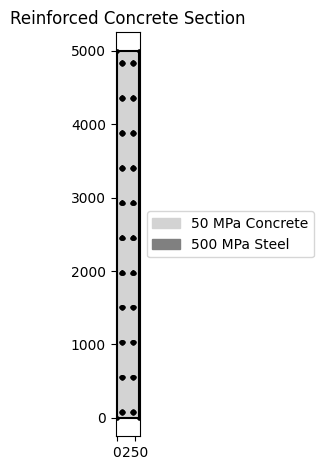

<Axes: title={'center': 'Reinforced Concrete Section'}>

In [3]:
beam = sp_ps.rectangular_section(d=5000, b=300, material=concrete)


beam = add_bar_rectangular_array(
    geometry=beam,
    area=310,
    material=steel,
    n_x=2,
    x_s=300 / 2,
    n_y = 11,
    y_s = 5000/10.5,
    anchor=(75, 75),
)

conc_sec = ConcreteSection(beam)
conc_sec.plot_section()

In [4]:
sag_res = conc_sec.ultimate_bending_capacity()
hog_res = conc_sec.ultimate_bending_capacity(theta=np.pi)
weak_res = conc_sec.ultimate_bending_capacity(theta=np.pi / 2)

In [5]:
sag_res.print_results()
hog_res.print_results()
weak_res.print_results()

            Ultimate Bending Results            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Property                     ┃         Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Bending Angle - theta        │  0.000000e+00 │
│ Neutral Axis Depth - d_n     │  2.305855e+02 │
│ Neutral Axis Parameter - k_u │  4.681940e-02 │
│ Axial Force                  │  1.928334e+00 │
│ Bending Capacity - m_x       │  6.885725e+09 │
│ Bending Capacity - m_y       │ -2.142042e-07 │
│ Bending Capacity - m_xy      │  6.885725e+09 │
└──────────────────────────────┴───────────────┘

            Ultimate Bending Results            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Property                     ┃         Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Bending Angle - theta        │  3.141593e+00 │
│ Neutral Axis Depth - d_n     │  2.180394e+02 │
│ Neutral Axis Parameter - k_u │  4.507829e-02 │
│ Axial Force                  │ -6.850207e+00 │
│ Bending Capacity - m_x       │ -6.682335e+09 │
│ Bending Capacity - m_y       │ -1.024455e-07 │
│ Bending Capacity - m_xy      │  6.682335e+09 │
└──────────────────────────────┴───────────────┘

            Ultimate Bending Results            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Property                     ┃         Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Bending Angle - theta        │  1.570796e+00 │
│ Neutral Axis Depth - d_n     │  1.572464e+01 │
│ Neutral Axis Parameter - k_u │  6.988730e-02 │
│ Axial Force                  │  7.603763e+01 │
│ Bending Capacity - m_x       │  1.243676e+08 │
│ Bending Capacity - m_y       │ -4.047747e+08 │
│ Bending Capacity - m_xy      │  4.234499e+08 │
└──────────────────────────────┴───────────────┘

In [6]:
print(f"M_x+ = {sag_res.m_xy / 1e6:.2f} kN.m")
print(f"M_x- = {hog_res.m_xy / 1e6:.2f} kN.m")
print(f"M_y = {weak_res.m_xy / 1e6:.2f} kN.m")

M_x+ = 6885.73 kN.m
M_x- = 6682.33 kN.m
M_y = 423.45 kN.m


In [7]:
ultimate_stress_pure = conc_sec.calculate_ultimate_stress(
    ultimate_results=sag_res
)

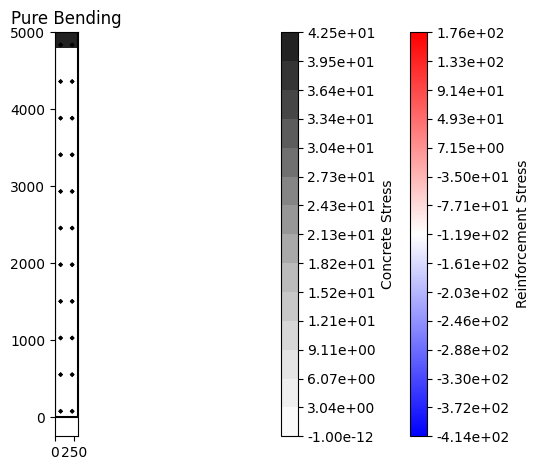

<Axes: title={'center': 'Pure Bending'}>

In [8]:
ultimate_stress_pure.plot_stress(title="Pure Bending")

In [9]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

x = np.array([0, 0.5, 1.0, 1.5, 2.0]) # Stations in meters
M = np.array([0, 15.2, 25.5, 12.1, 0]) # Moments in kNm (from ETABS)

E = 30e6  # kPa (kN/m^2)
I = 0.002 # m^4
EI = E * I

curvature = M / EI

slope = cumulative_trapezoid(curvature, x, initial=0)
deflection = cumulative_trapezoid(slope, x, initial=0)


max_deflection = np.max(np.abs(deflection))

print(f"Maximum Bending Deflection: {max_deflection:.4f} mm")

Maximum Bending Deflection: 0.0005 mm
